# Figure 1

## Visual Plot

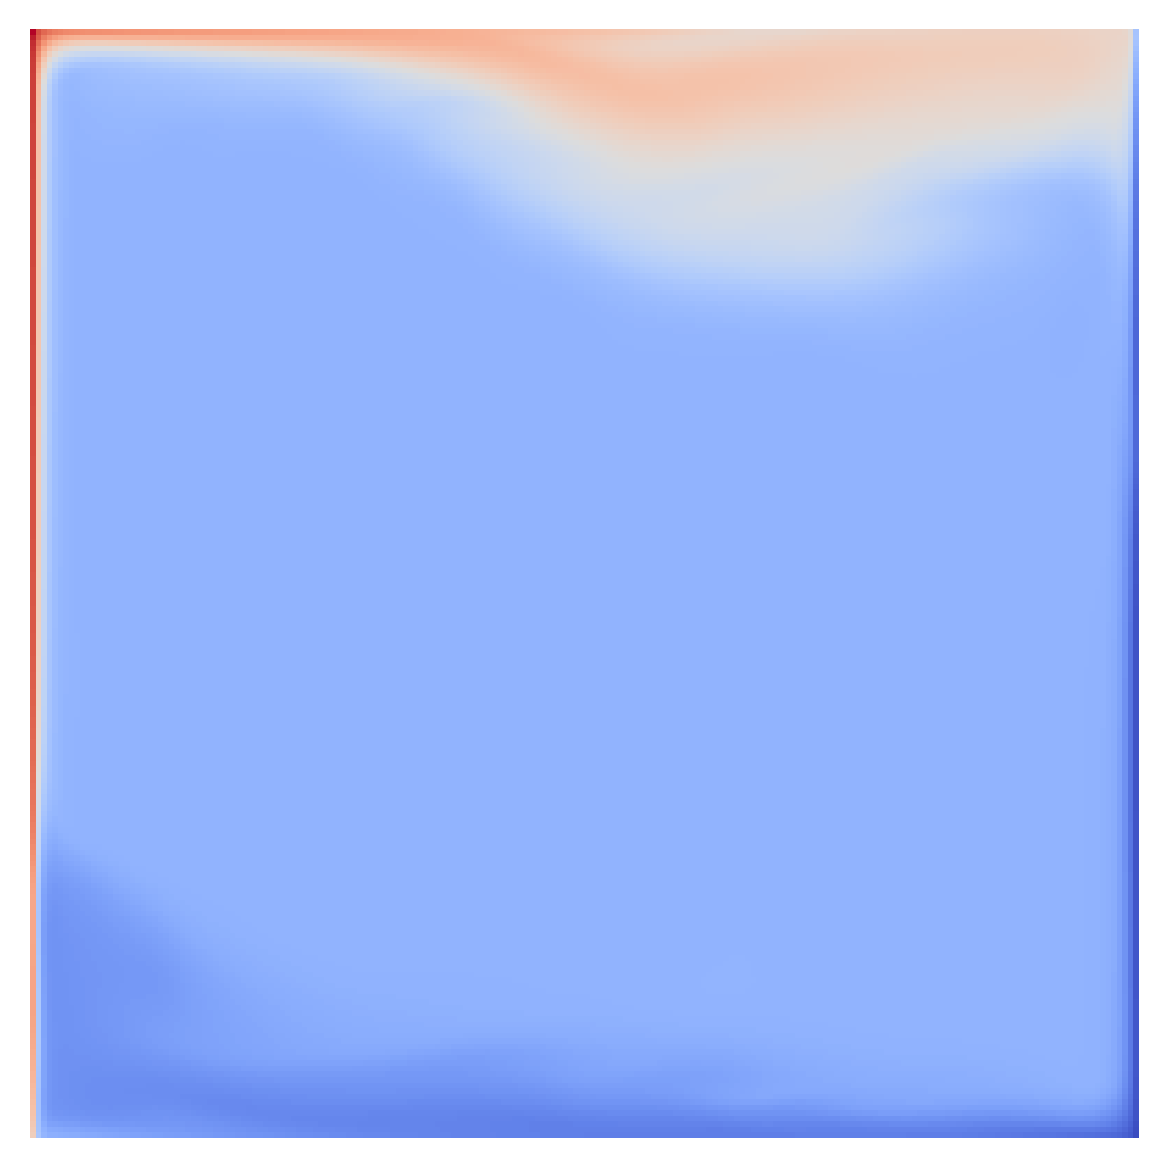

In [40]:
from repitframework.plot_utils import load_metrics, plot_everything
from repitframework.config import BaseConfig, TrainingConfig
from pathlib import Path
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


single_training_errors = Path("/home/shilaj/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_case1_study/10000timesteps/single_training/natural_convection_case1/errors.ndjson")
xrepit_training_errors = Path("/home/shilaj/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_case1_study/10000timesteps/2epochs5res/natural_convection_case1/errors.ndjson")
single_errors = load_metrics(single_training_errors)
xrepit_errors = load_metrics(xrepit_training_errors)


t_100_single_training = Path("/home/shilaj/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_case1_study/10000timesteps/single_training/natural_convection_case1/T_12.0_predicted.npy")
t_100_xrepit = Path("/home/shilaj/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_case1_study/10000timesteps/2epochs5res/natural_convection_case1/T_20.0.npy")
t100_single = np.load(t_100_single_training).reshape(200, 200)
t100_xrepit = np.load(t_100_xrepit).reshape(200, 200)


# Turn off the entire axis 
# 1. Define your lowest and highest colors
# You can use hex codes, RGB tuples, or standard color names.
lowest_color = "#0095FF"  # Navy Blue
highest_color = "#FF0026" # Yellow

# Optional: Add an intermediate color for a multi-color gradient
# mid_color = 'white'
# colors = [lowest_color, mid_color, highest_color]

colors = [lowest_color, highest_color]

# 2. Create the custom colormap
custom_cmap = LinearSegmentedColormap.from_list('my_cmap', colors)
plt.axis('off')
plt.imshow(t100_xrepit, origin='lower', cmap="coolwarm")

## Residual divergence

In [5]:
"""
Panel B: Residual divergence plot (Nature style)

Inputs:
	t          : 1D list/array of timesteps (len N)
	res_cfd    : 1D list/array of scaled residuals for CFD/ground truth (len N)
	res_ml     : 1D list/array of scaled residuals for single-training ML (len N)

Usage:
	plot_residual_divergence(t, res_cfd, res_ml,
							 factor=100.0,
							 outfile="panelB_residual_divergence.png")
"""

from __future__ import annotations

from typing import Sequence
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from repitframework.Metrics import residual_mass
from pathlib import Path
from repitframework.plot_utils import load_metrics

keyword = {"single_training": "Single training", "2epochs5res": "XRePIT (ours)"}
key = 1


prediction_metrics = Path(f"/data/disk3/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_case1_study/10000timesteps/{list(keyword.keys())[key]}/prediction_metrics.ndjson")
metrics = load_metrics(prediction_metrics)
time_list = metrics["Running Time"]

ground_truth_dir = Path("/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection_case1")
prediction_dir = Path(f"/data/disk3/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_case1_study/10000timesteps/{list(keyword.keys())[key]}/natural_convection_case1")


residuals = {
	"ground_truth": [],
	"prediction": [],
	"timesteps": [],
}


for time in time_list:
	ground_truth = np.load(ground_truth_dir / f"U_{time}.npy").reshape(200,200, 3)[...,:2]
	predicted = np.load(prediction_dir / f"U_{time}_predicted.npy").reshape(200,200, 2)
	res_gt = residual_mass(ground_truth)
	res_pred = residual_mass(predicted)
	residuals["ground_truth"].append(res_gt)
	residuals["prediction"].append(res_pred)
	residuals["timesteps"].append((round(time,2)*100)-1000)
	if time > 20.0:
		break


label1 = "OpenFOAM (reference)"
label2 = list(keyword.values())[key]

# --- Palette (from your list) ---
COL_BLUE_DARK = "#007CD3"   # CFD line
COL_BLUE_LIGHT = "#C7E8FF"  # gap tint near CFD
COL_ORANGE_DARK = "#D5A000" # ML-only line
COL_YELLOW_LIGHT = "#FAFFB7"  # gap tint near ML
COL_RED_LIGHT = "#FFE4E6"   # divergence band


def _to_np(x: Sequence[float]) -> np.ndarray:
	a = np.asarray(x, dtype=float).ravel()
	if a.ndim != 1:
		raise ValueError("Inputs must be 1D sequences.")
	return a


def plot_residual_divergence(
	t: Sequence[float],
	res_cfd: Sequence[float],
	res_ml: Sequence[float],
	*,
	factor: float = 100.0,
	outfile: str = "panelB_residual_divergence.png",
):
	"""Plot log-scale residuals with shaded divergence and gap fill."""
	t = _to_np(t)
	cfd = _to_np(res_cfd)
	ml = _to_np(res_ml)

	if not (len(t) == len(cfd) == len(ml)):
		raise ValueError("t, res_cfd, res_ml must have the same length.")

	# Find first index where ML exceeds CFD by a multiplicative factor
	ratio = np.divide(ml, np.maximum(cfd, 1e-30))
	idx_div = np.argmax(ratio >= factor)
	has_div = ratio.max() >= factor

	# Figure / axes
	mpl.rcParams.update({
		"figure.dpi": 150,
		"savefig.dpi": 600,
		"font.size": 12,
		"axes.linewidth": 1.2,
		"axes.labelsize": 15,
		"axes.titlesize": 18,
		"xtick.labelsize": 12,
		"ytick.labelsize": 12,
		"legend.fontsize": 13,
	})

	fig, ax = plt.subplots(figsize=(6.0, 4.6))  # single, uncluttered chart

	# Plot lines
	ax.plot(t, cfd, color=COL_BLUE_DARK, lw=2.2, label=label1)
	ax.plot(t, ml, color=COL_ORANGE_DARK, lw=2.2, label=label2)

	# Fill the gap between curves to emphasize separation (use light tints)
	upper = np.maximum(cfd, ml)
	lower = np.minimum(cfd, ml)
	ax.fill_between(
		t, lower, upper,
		color=COL_YELLOW_LIGHT, alpha=0.5, linewidth=0,
		zorder=1,
	)

	# Shade divergence region (ML ≥ factor × CFD)
	if has_div:
		t_div_start = t[idx_div]
		ax.axvspan(
			t_div_start, t[-1],
			color=COL_RED_LIGHT, alpha=0.35, lw=0, zorder=0,
		)
		ax.annotate(
			f"ML diverges (≥ {int(factor)}× CFD)",
			xy=(t_div_start, ml[idx_div]),
			xytext=(t_div_start, upper.max()*4.2),
			textcoords="data",
			arrowprops=dict(arrowstyle="->", lw=1.2, color="black"),
			ha="left", va="bottom",
		)

	# Axes styling (Nature-like: clean, log-y, subtle grid)
	ax.set_yscale("log")
	ymin = max(min(cfd.min(), ml.min()) * 0.9, 1e-8)
	ymax = max(cfd.max(), ml.max()) * 1.3
	ax.set_ylim(ymin, 1e6)

	ax.set_xlabel("Timesteps")
	ax.set_ylabel("Scaled continuity residual")

	ax.grid(True, which="major", ls="--", lw=0.6, alpha=0.4)
	ax.grid(True, which="minor", ls=":", lw=0.5, alpha=0.25)

	# Legend outside the data for clarity
	leg = ax.legend(
		loc="upper left",
		frameon=True,
		fancybox=False,
		framealpha=0.9,
		borderpad=0.6,
	)
	leg.get_frame().set_linewidth(0.8)

	# Tight layout & save
	fig.tight_layout()
	fig.savefig(outfile, bbox_inches="tight")
	plt.close(fig)


# --------------------
# Example (remove or adapt):
# t = np.arange(10, 20.1, 0.1)
# res_cfd = 1.0 + 0.02*np.sin(0.5*(t-10))
# res_ml = 1.0 + np.exp(0.9*(t-10)) * 1e-3
# plot_residual_divergence(t, res_cfd, res_ml, factor=100.0)
# --------------------
plot_residual_divergence(
	t=residuals["timesteps"],
	res_cfd=residuals["ground_truth"]/residuals["ground_truth"][0],
	res_ml=residuals["prediction"]/residuals["ground_truth"][0],
	factor=100.0,
	outfile=f"panelB_residual_divergence_{label2}.png"
)

## Time consumption plot

In [ ]:
time_taken = {
	"XRePIT-CaseA-2D-FVMN": {
		"solver-2D": 4252.880527963149,
		"XRePIT": 2075.8295023795217},
	"XRePIT-CaseA-2D-FVFNO": {
		"solver-2D": 4252.880527963149,
		"XRePIT": 4252.880527963149/1.44},
	"XRePIT-CaseA-3D-FVMN": {
		"solver-3D": 3679.507182876139,
		"XRePIT": 919.6060710000003},
	"XRePIT-CaseB-2D-FVMN": {
		"solver-2D": 7498.4191196279,
		"XRePIT": 3354.477344342973},
	"XRePIT-CaseC-2D-FVMN": {
		"solver-2D": 7514.979543524059,
		"XRePIT": 3466.7458462901413}
}

"""
Time reduction: segmented bar plot (XRePIT vs Solver)

- Bar length equals baseline solver wall-clock time.
- Left segment (0 → XRePIT) = XRePIT time (green).
- Right segment (XRePIT → Solver) = remaining time if using the solver (blue).
- Annotates ×speedup and % reduction.

Palette:
  Solver dark blue:  #007CD3
  XRePIT dark green: #00C70D
"""

from __future__ import annotations

from typing import Dict, Tuple, List
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# --- Palette ---
COL_SOLVER = "#FC7F91"   # dark blue
COL_XREPIT = "#4A83AC"   # dark green

# --- Matplotlib style tuned for journal figures ---
mpl.rcParams.update({
	"figure.dpi": 150,
	"savefig.dpi": 600,
	"font.size": 12,
	"axes.labelsize": 14,
	"axes.titlesize": 16,
	"axes.linewidth": 1.2,
	"xtick.labelsize": 12,
	"ytick.labelsize": 12,
	"legend.fontsize": 12,
	"axes.spines.top": False,
	"axes.spines.right": False,
})


def nice_label(key: str) -> str:
	"""Turn 'XRePIT-CaseA-2D-FVMN' → 'Case A · 2D · FVMN'."""
	parts = key.split("-")
	if len(parts) >= 4:
		case = parts[1].replace("Case", "Case ")
		return f"{case} · {parts[2]} · {parts[3]}"
	return key


def extract_times(tbl: Dict[str, Dict[str, float]]) -> Tuple[List[str], np.ndarray, np.ndarray]:
	"""Return labels, solver_times, xrepit_times. Detect 'solver-*' key per entry."""
	labels, t_solver, t_xr = [], [], []
	for k, d in tbl.items():
		solver_key = next((kk for kk in d.keys() if kk.startswith("solver")), None)
		if solver_key is None:
			raise KeyError(f"No 'solver-*' key found in {k}.")
		labels.append(nice_label(k))
		t_solver.append(float(d[solver_key]))
		t_xr.append(float(d["XRePIT"]))
	return labels, np.asarray(t_solver), np.asarray(t_xr)


def secs_fmt(x, _pos=None) -> str:
	return f"{int(round(x)):,}".replace(",", " ") + " s"


def plot_segmented_bars(time_taken: Dict[str, Dict[str, float]],
						outfile: str = "xrepit_segmented_bars.png") -> None:
	labels, t_solver, t_xr = extract_times(time_taken)

	# Sort by % reduction (desc) so biggest win is on top
	reduction = 1.0 - (t_xr / t_solver)
	order = np.argsort(-reduction)
	labels = [labels[i] for i in order]
	t_solver = t_solver[order]
	t_xr = t_xr[order]
	reduction = reduction[order]
	speedup = t_solver / t_xr

	# Clamp in case any XR > solver (shouldn't happen, but be safe)
	extra = np.maximum(t_solver - t_xr, 0.0)

	y = np.arange(len(labels))
	h = 0.6  # bar height

	fig, ax = plt.subplots(figsize=(7.4, 4.8))

	# Left segment: XRePIT time (green)
	ax.barh(y, t_xr, height=h, color=COL_XREPIT, edgecolor="none", label="XRePIT (ours)")

	# Right segment: remainder up to solver time (blue), starting at XRePIT time
	ax.barh(y, extra, left=t_xr, height=h, color=COL_SOLVER, edgecolor="none",
			label="OpenFOAM (reference)")

	# Annotations (speedup and % reduction) near right edge of the green segment
	for yi, xr, sp, rp in zip(y, t_xr, speedup, reduction):
		if sp < 1.5: 
			xr -= 850
		ax.annotate(
			f"×{sp:.2f} ; −{rp*100:.0f}%",
			xy=(xr, yi),
			xytext=(6, 0),
			textcoords="offset points",
			va="center", ha="left", fontsize=11, color="black",
		)

	# Labels and formatting
	ax.set_yticks(y, labels)
	ax.set_xlabel("Wall-clock time")
	ax.xaxis.set_major_formatter(FuncFormatter(secs_fmt))

	# Grid & limits
	ax.grid(axis="x", which="major", ls="--", lw=0.7, alpha=0.35)
	xmax = max(t_solver.max(), t_xr.max()) * 1.25
	ax.set_xlim(0, xmax)

	# Legend
	ax.legend( loc="upper right", frameon=True, framealpha=0.95, borderpad=0.5)

	fig.tight_layout()
	fig.savefig(outfile, bbox_inches="tight")
	plt.close(fig)


plot_segmented_bars(time_taken)


# Figure 3

## Acceleration vs scaled residual vs MSE

In [ ]:
#!/usr/bin/env python3
"""
Hybrid loop hyper-parameter analysis (line plot only, Nature style)
x-axis: scaled residual threshold (ε_th)
y-axis: acceleration factor (ψ)
Lines: different transfer-learning epochs
"""

from __future__ import annotations
from typing import Dict, List, Tuple
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# ---- INPUT ----
acceleration_data: Dict[str, Dict[str, float]] = {
	"2":   {"5": 2.04, "10": 2.36, "100": 3.68},
	"10": {"5": 1.21, "10": 1.45, "100": 2.29},
}

mse_data: Dict[str, Dict[str, float]] = {
	"2":   {"5": 0.0, "10": 0.0, "100": 0.0},
	"10": {"5": 0.0, "10": 0.0, "100": 0.0},
}


ground_truth_dir = Path("/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection_case1_backup")
prediction_dir = "/home/shilaj/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_case1_study/10000timesteps/{}epochs{}res"

for key, val in mse_data.items():
	for k in val.keys():
		prediction_metrics = Path(prediction_dir.format(key, k) + "/prediction_metrics.ndjson")
		metrics = load_metrics(prediction_metrics)
		time_list = metrics["Running Time"]
		prediction_path = Path(prediction_dir.format(key, k)) / "natural_convection_case1"
		mse = 0.0
		count = 0
		for time in time_list:
			gt = np.load(ground_truth_dir / f"T_{time}.npy").reshape(200,200)
			pred = np.load(prediction_path / f"T_{time}_predicted.npy").reshape(200,200)
			# Calculate L2 error
			# mse += np.linalg.norm(gt - pred)/np.linalg.norm(gt)
			mse += np.mean((gt - pred)**2)
			count += 1
		mse /= count
		mse_data[key][k] = mse

In [ ]:
#!/usr/bin/env python3
"""
Hybrid loop hyper-parameter analysis:
Single panel with twin y-axes:
  - Solid lines: Acceleration (psi) vs residual threshold
  - Dashed lines: Temperature MSE vs residual threshold
  - Same color per epoch across both metrics (2 ep=green, 100 ep=orange)

Inputs:
  acceleration_data = { "2": {"5": 2.04, "10": 2.36, "100": 3.68}, ... }
  mse_data          = { "2": {"5": <mse>, "10": <mse>, "100": <mse>}, ... }
"""

from __future__ import annotations
from typing import Dict, List, Tuple
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# --- Palette (from your list) ---
COL_EPOCH = {
	2:   "#00C70D",  # dark green
	100: "#D5A000",  # dark orange
}
GRID_COL = "#000000"  # very light via alpha

# --- Matplotlib (journal-friendly) ---
mpl.rcParams.update({
	"figure.dpi": 150,
	"savefig.dpi": 600,
	"font.size": 12,
	"axes.labelsize": 13,
	"axes.titlesize": 15,
	"axes.linewidth": 1.2,
	"xtick.labelsize": 11,
	"ytick.labelsize": 11,
	"legend.fontsize": 11,
	"axes.spines.top": False,
	"axes.spines.right": False,  # we'll re-enable right spine on twin axis only
})

def _sorted_axes(d1: Dict[str, Dict[str, float]], d2: Dict[str, Dict[str, float]]) -> Tuple[List[int], List[int]]:
	epochs = sorted({*(int(e) for e in d1.keys()), *(int(e) for e in d2.keys())})
	thresholds = sorted({*(int(k) for dd in d1.values() for k in dd.keys()),
						 *(int(k) for dd in d2.values() for k in dd.keys())})
	return epochs, thresholds

def _series_for_epoch(d: Dict[str, Dict[str, float]], e: int, ths: List[int]) -> List[float]:
	# Returns list in threshold order; missing entries become np.nan
	return [d.get(str(e), {}).get(str(t), np.nan) for t in ths]

def plot_combined(accel: Dict[str, Dict[str, float]],
				  mse: Dict[str, Dict[str, float]],
				  outfile: str = "hyperparams_accel_mse.png") -> None:
	epochs, thresholds = _sorted_axes(accel, mse)

	# Prepare figure and axes
	fig, ax_psi = plt.subplots(figsize=(6.6, 4.2))
	ax_mse = ax_psi.twinx()  # secondary y-axis
	ax_mse.spines["right"].set_visible(True)

	# Log-x for 5→10→100
	ax_psi.set_xscale("log")
	ax_psi.set_xticks(thresholds)
	ax_psi.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
	ax_psi.set_xlim(min(thresholds)*0.9, max(thresholds)*1.2)

	# Collect ranges
	psi_vals = []
	mse_vals = []
	for e in epochs:
		psi_vals += [v for v in _series_for_epoch(accel, e, thresholds) if np.isfinite(v)]
		mse_vals += [v for v in _series_for_epoch(mse,   e, thresholds) if np.isfinite(v)]

	# Reasonable y-lims
	ymin_psi = max(1.0, min(psi_vals)*0.9) if psi_vals else 1.0
	ymax_psi = (max(psi_vals) if psi_vals else 2.0) * 1.10
	ymin_mse = (min(mse_vals) if mse_vals else 0.0) * 0.9
	ymax_mse = (max(mse_vals) if mse_vals else 1.0) * 1.10

	# Plot each epoch
	handles = []
	labels = []
	for e in epochs:
		color = COL_EPOCH.get(e, "#007CD3")  # default to dark blue if new epoch appears
		psi_y = _series_for_epoch(accel, e, thresholds)
		mse_y = _series_for_epoch(mse,   e, thresholds)

		# Acceleration (solid)
		h1, = ax_psi.plot(
			thresholds, psi_y,
			lw=2.2, marker="o", ms=6, color=color, solid_capstyle="round",
			label=f"{e} epochs — ψ"
		)
		# Annotate ×ψ (minimal, with white stroke)
		for xt, yt in zip(thresholds, psi_y):
			if np.isfinite(yt):
				ax_psi.annotate(
					f"×{yt:.2f}",
					xy=(xt, yt), xytext=(0, 9), textcoords="offset points",
					ha="center", va="bottom", fontsize=10, color="#222222",
					path_effects=[pe.withStroke(linewidth=2.2, foreground="white")]
				)

		# MSE (dashed), same color, different marker
		h2, = ax_mse.plot(
			thresholds, mse_y,
			lw=2.0, ls="--", marker="s", ms=5, color=color, alpha=0.95,
			label="Error (MSE)"
		)

		handles += [h1, h2]
		labels  += [f"{e} epochs — ψ", f"{e} epochs — MSE"]

	# Axes labels, grids, limits
	ax_psi.set_xlabel(r"Scaled residual threshold, $\varepsilon_{\mathrm{th}}$")
	ax_psi.set_ylabel(r"Acceleration factor, $\psi$")
	ax_mse.set_ylabel(r"Temperature MSE")

	ax_psi.set_ylim(ymin_psi, ymax_psi)
	ax_mse.set_ylim(ymin_mse, ymax_mse)

	ax_psi.grid(True, which="major", ls="--", lw=0.7, alpha=0.35, color=GRID_COL)

	# Legend: combine handles from both axes
	leg = ax_psi.legend(handles, labels, loc="best", frameon=True, framealpha=0.95, borderpad=0.5)
	leg.get_frame().set_linewidth(0.8)

	fig.tight_layout()
	fig.savefig(outfile, bbox_inches="tight")
	plt.close(fig)

if __name__ == "__main__":
	plot_combined(acceleration_data, mse_data)


## Calculate mean squared error

In [ ]:
ground_truth_dir = "/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection_{}_backup"
prediction_dir = "/home/shilaj/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_{}_study/10000timesteps/2epochs5res/natural_convection_{}"
prediction_metrics = "/home/shilaj/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_{}_study/10000timesteps/2epochs5res/prediction_metrics.ndjson"

error_dict = {
	"case1": {
		"temperature_mse": [],
		"velocity_mse": [],
		"temperature_l2": [],
		"velocity_l2": []
	},
	"case2": {
		"temperature_mse": [],
		"velocity_mse": [],
		"temperature_l2": [],
		"velocity_l2": []
		},
	"case3": {
		"temperature_mse": [],
		"velocity_mse": [],
		"temperature_l2": [],
		"velocity_l2": []
	}
}

for case in ["case1", "case2", "case3"]:
	metrics = load_metrics(prediction_metrics.format(case))
	time_list = metrics["Running Time"]
	prediction_path = Path(prediction_dir.format(case, case))
	ground_truth_path = Path(ground_truth_dir.format(case))
	velocity_mse = 0.0
	temperature_mse = 0.0
	velocity_l2 = 0.0
	temperature_l2 = 0.0

	full_time_list = np.arange(min(time_list), max(time_list), 0.01).round(2).tolist()

	for time in full_time_list:
		if time in time_list: 
			pred_u = np.load(prediction_path / f"U_{time}_predicted.npy").reshape(200,200,2)
			pred_t = np.load(prediction_path / f"T_{time}_predicted.npy").reshape(200,200)
		else:
			pred_u = np.load(prediction_path / f"U_{time}.npy").reshape(200,200,3)[]
			pred_t = np.load(prediction_path / f"T_{time}.npy").reshape(200,200)

		gt_u = np.load(ground_truth_path / f"U_{time}.npy").reshape(200,200,3)[...,:2]
		gt_t = np.load(ground_truth_path / f"T_{time}.npy").reshape(200,200)
		# Calculate L2 error
		velocity_l2 = np.linalg.norm(gt_u - pred_u)/np.linalg.norm(gt_u)
		temperature_l2 = np.linalg.norm(gt_t - pred_t)/np.linalg.norm(gt_t)
		# Calculate MSE
		velocity_mse = np.mean((gt_u - pred_u)**2)
		temperature_mse = np.mean((gt_t - pred_t)**2)

		error_dict[case]["velocity_l2"].append(velocity_l2)
		error_dict[case]["temperature_l2"].append(temperature_l2)
		error_dict[case]["velocity_mse"].append(velocity_mse)
		error_dict[case]["temperature_mse"].append(temperature_mse)
		
	

FileNotFoundError: [Errno 2] No such file or directory: '/home/shilaj/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_caseA_study/10000timesteps/2epochs5res/prediction_metrics.ndjson'

In [ ]:
#!/usr/bin/env python3
"""
Nature-style error visualization with moving average and std bands.

- Two panels (shared x): Temperature (top), Velocity magnitude (bottom)
- For each case, plot:
	• Moving-average line (smooth, connected)
	• Same-color ±1σ band (lighter alpha)
	• Sparse markers (~10) along the smoothed line
- Works with either metric='mse' or metric='l2' using your error_dict schema.

Usage:
	plot_errors_moving_avg(error_dict, metric="mse",
						   xlabel="Timestep", outfile="errors_movingavg.png")
"""

from __future__ import annotations
from typing import Dict, List, Tuple
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- Your palette (consistent with earlier figures) ----
COL_CASE = {
	"caseA": "#007CD3",  # dark blue
	"caseB": "#00C70D",  # dark green
	"caseC": "#D5A000",  # dark orange
}
ALPHA_BAND = 0.22  # std-band transparency

# ---- Matplotlib journal style ----
mpl.rcParams.update({
	"figure.dpi": 150,
	"savefig.dpi": 600,
	"font.size": 12,
	"axes.labelsize": 13,
	"axes.titlesize": 15,
	"axes.linewidth": 1.2,
	"xtick.labelsize": 11,
	"ytick.labelsize": 11,
	"legend.fontsize": 11,
	"axes.spines.top": False,
	"axes.spines.right": False,
})


def _moving_mean_std(y: np.ndarray, win: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
	"""
	Moving mean and std with a uniform window (valid mode).
	Returns (x_centers, mean, std), where x_centers are 1-based 'step' centers.
	"""
	y = np.asarray(y, dtype=float).ravel()
	n = y.size
	if n == 0 or win <= 1 or win > n:
		# fallback: no smoothing possible
		x = np.arange(1, n + 1, dtype=float)
		return x, y, np.zeros_like(y)

	kernel = np.ones(win, dtype=float)
	mean = np.convolve(y, kernel, mode="valid") / win
	mean_sq = np.convolve(y * y, kernel, mode="valid") / win
	var = np.clip(mean_sq - mean**2, 0.0, None)
	std = np.sqrt(var)

	# centers in 1-based “step” coordinates
	centers = np.arange(0, n - win + 1, dtype=float) + (win - 1) / 2.0 + 1.0
	return centers, mean, std


def _auto_window(n: int) -> int:
	"""
	Choose a window that yields ~10 segments while remaining >=5 and <= n.
	"""
	if n <= 10:
		return max(3, n)  # tiny series: no real smoothing; just plot as-is
	return max(5, min(n, n // 10))


def _downsample_indices(m: int, k: int = 10) -> np.ndarray:
	"""
	Pick ~k evenly spaced indices from 0..m-1 for placing small markers.
	"""
	if m <= k:
		return np.arange(m, dtype=int)
	return np.unique(np.linspace(0, m - 1, k, dtype=int))


def plot_errors_moving_avg(
	error_dict: Dict[str, Dict[str, List[float]]],
	metric: str = "mse",           # or "l2"
	xlabel: str = "Timestep",
	outfile: str = "errors_movingavg.png",
) -> None:
	assert metric in {"mse", "l2"}, "metric must be 'mse' or 'l2'"
	key_T = f"temperature_{metric}"
	key_U = f"velocity_{metric}"

	cases = [k for k in ["case1", "case2", "case3"] if k in error_dict]

	fig, (axT, axU) = plt.subplots(
		nrows=2, ncols=1, figsize=(6.8, 5.2), sharex=True,
		gridspec_kw=dict(hspace=0.15)
	)

	# --- Temperature panel ---
	plotted_T = []
	for case in cases:
		color = COL_CASE.get(case, "#444444")
		y = np.asarray(error_dict[case].get(key_T, []), dtype=float)
		if y.size == 0:
			continue
		w = _auto_window(len(y))
		x, mu, sd = _moving_mean_std(y, w)
		plotted_T.append(mu)

		axT.fill_between(x, mu - sd, mu + sd, color=color, alpha=ALPHA_BAND, linewidth=0)
		axT.plot(x, mu, color=color, lw=2.2, solid_capstyle="round", label=case.capitalize())

		# sparse markers (~10) along the smoothed curve
		idx = _downsample_indices(len(mu), k=10)
		axT.plot(x[idx], mu[idx], linestyle="none", marker="o", ms=4.5,
				 color=color, markeredgecolor="white", markeredgewidth=0.6)

	axT.set_ylabel("Temperature")
	if plotted_T:
		allT = np.concatenate(plotted_T)
		ymin, ymax = float(np.nanmin(allT)), float(np.nanmax(allT))
		# use_log = (ymax / max(ymin, 1e-16)) > 50.0
		use_log = True
		if use_log:
			axT.set_yscale("log")
			axT.set_ylim(max(ymin * 0.8, 1e-16), ymax * 1.25)
			axT.grid(True, which="major", ls="--", lw=0.7, alpha=0.35)
			axT.grid(True, which="minor", ls=":", lw=0.5, alpha=0.22)
		else:
			pad = 0.08 * (ymax - ymin if ymax > ymin else 1.0)
			axT.set_ylim(ymin - pad, ymax + 1.2 * pad)
			axT.grid(True, which="major", ls="--", lw=0.7, alpha=0.35)

	# axT.legend(frameon=True, framealpha=0.95, borderpad=0.5)

	# --- Velocity-magnitude panel ---
	plotted_U = []
	for case in cases:
		color = COL_CASE.get(case, "#444444")
		y = np.asarray(error_dict[case].get(key_U, []), dtype=float)
		if y.size == 0:
			continue
		w = _auto_window(len(y))
		x, mu, sd = _moving_mean_std(y, w)
		plotted_U.append(mu)

		axU.fill_between(x, mu - sd, mu + sd, color=color, alpha=ALPHA_BAND, linewidth=0)
		axU.plot(x, mu, color=color, lw=2.2, solid_capstyle="round", label=case.capitalize())

		idx = _downsample_indices(len(mu), k=10)
		axU.plot(x[idx], mu[idx], linestyle="none", marker="o", ms=4.5,
				 color=color, markeredgecolor="white", markeredgewidth=0.6)

	axU.set_ylabel("Velocity magnitude")
	axU.set_xlabel(xlabel)
	if plotted_U:
		allU = np.concatenate(plotted_U)
		ymin, ymax = float(np.nanmin(allU)), float(np.nanmax(allU))
		# use_log = (ymax / max(ymin, 1e-16)) > 50.0
		use_log = True
		if use_log:
			axU.set_yscale("log")
			axU.set_ylim(max(ymin * 0.8, 1e-16), ymax * 1.25)
			axU.grid(True, which="major", ls="--", lw=0.7, alpha=0.35)
			axU.grid(True, which="minor", ls=":", lw=0.5, alpha=0.22)
		else:
			pad = 0.08 * (ymax - ymin if ymax > ymin else 1.0)
			axU.set_ylim(ymin - pad, ymax + 1.2 * pad)
			axU.grid(True, which="major", ls="--", lw=0.7, alpha=0.35)

	axU.legend(frameon=True, framealpha=0.95, borderpad=0.5)

	fig.suptitle(f"{'MSE' if metric == 'mse' else 'L2'} error for different boundary cases ", fontsize=16)
	fig.tight_layout()
	fig.savefig(outfile, bbox_inches="tight")
	plt.close(fig)



# Choose metric = "mse" or "l2"
plot_errors_moving_avg(error_dict, metric="l2", xlabel="Timestep")


/tmp/ipykernel_1187338/2857380544.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


## Nature style probe comparison

In [ ]:
import json
from pathlib import Path
from typing import Dict

def load(filepath: str) -> Dict:
	with open(filepath, "r") as f:
		data = json.load(f)
	return data
probes_path = "/home/shilaj/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_case1_study/10000timesteps/2epochs5res/natural_convection_case1/probes_data.json"
probes_data = load(probes_path)

In [ ]:
#!/usr/bin/env python3
"""
Two-panel probe plot (Nature style) with moving averages and std. dev. shading.

- Top panel:    Probes t1, t2, t3 (GT vs. Predicted)
- Bottom panel: Probes b1, b2, b3 (GT vs. Predicted)

Features:
-   Calculates moving average to smooth trends in lengthy/noisy data.
-   Shades the standard deviation around the mean for visual clarity.
-   Uses a shared x-axis and a single, consolidated figure-level legend.
-   Logarithmic y-axis for wide dynamic range.
-   Professional, "Nature-ready" styling.
"""
from __future__ import annotations
from typing import Dict, Tuple
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Colors for the 3 probes (consistent across top/bottom) ---
PROBE_COLORS = {
	"1": "#007CD3",  # Muted Blue
	"2": "#00C70D",  # Muted Green
	"3": "#FC7F91",  # Muted Orange
}

# --- Matplotlib styling (Nature-like) ---
mpl.rcParams.update({
	"figure.dpi": 200,
	"savefig.dpi": 600,
	"font.size": 10,
	"axes.labelsize": 11,
	"axes.titlesize": 12,
	"axes.titleweight": "bold",
	"axes.labelweight": "bold",
	"axes.linewidth": 1.0,
	"xtick.labelsize": 9,
	"ytick.labelsize": 9,
	"legend.fontsize": 10,
	"axes.spines.top": False,
	"axes.spines.right": False,
})


def _moving_average_std(y: np.ndarray, window: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
	"""Calculates moving average and standard deviation using pandas for robustness."""
	if y.size < window:
		return np.array([]), np.array([]), np.array([])
	
	# Use pandas for a robust and fast rolling window calculation
	series = pd.Series(y)
	rolling_mean = series.rolling(window=window).mean().to_numpy()
	rolling_std = series.rolling(window=window).std().to_numpy()
	
	# Valid indices (where the window has enough data)
	valid_indices = np.arange(window - 1, y.size)
	
	# Slicing removes the initial NaN values from rolling operation
	return rolling_mean[window-1:], rolling_std[window-1:], valid_indices


def _get_series(d: Dict, which: str, key: str, variable: str) -> np.ndarray:
	"""Fetches or computes the time series for a given variable."""
	if variable == "T":
		return np.asarray(d.get("T", {}).get(which, {}).get(key, []), dtype=float).ravel()
	
	elif variable == "U_mag":
		ux = np.asarray(d.get("U_x", {}).get(which, {}).get(key, []), dtype=float).ravel()
		uy = np.asarray(d.get("U_y", {}).get(which, {}).get(key, []), dtype=float).ravel()
		n = min(ux.size, uy.size)
		if n == 0:
			return np.array([], dtype=float)
		return np.sqrt(ux[:n]**2 + uy[:n]**2)
	return np.array([])


def _sanitize_positive(y: np.ndarray) -> np.ndarray:
	"""Ensure strictly positive values for log-axis by replacing non-positive with NaN."""
	y = np.asarray(y, dtype=float)
	y[y <= 1e-9] = np.nan # Use a small epsilon for stability
	return y


def _plot_panel(ax: plt.Axes, d: Dict, variable: str, wall_prefix: str, window_size: int):
	"""Plots 6 smoothed lines with std. dev. shading in one panel."""
	for j in ["1", "2", "3"]:
		key = f"{wall_prefix}{j}"
		color = PROBE_COLORS[j]

		gt_raw = _sanitize_positive(_get_series(d, "ground_truth", key, variable))
		pr_raw = _sanitize_positive(_get_series(d, "predicted", key, variable))

		# --- Ground Truth (Solid Line) ---
		if gt_raw.size > window_size:
			gt_mean, gt_std, x_gt = _moving_average_std(gt_raw, window_size)
			ax.plot(x_gt, gt_mean, color=color, lw=1.5, ls="-")
			ax.fill_between(x_gt, gt_mean - gt_std, gt_mean + gt_std, color=color, alpha=0.15, linewidth=0)

		# --- Predicted (Dotted Line) ---
		if pr_raw.size > window_size:
			pr_mean, pr_std, x_pr = _moving_average_std(pr_raw, window_size)
			ax.plot(x_pr, pr_mean, color=color, lw=1.5, ls="--")
			ax.fill_between(x_pr, pr_mean - pr_std, pr_mean + pr_std, color=color, alpha=0.15, linewidth=0)
	
	ax.set_yscale("log")
	ax.grid(True, which="major", ls="--", lw=0.5, color='gray', alpha=0.5)
	ax.grid(True, which="minor", ls=":", lw=0.3, color='gray', alpha=0.3)


def plot_wall_probes(
	data: Dict,
	variable: str = "T",
	xlabel: str = "Timestep",
	ylabel: str | None = None,
	outfile: str = "wall_probes_T.png",
	window_size: int = 50,
):
	"""Renders the final two-panel figure with a consolidated legend."""
	assert variable in {"T", "U_mag"}, "variable must be 'T' or 'U_mag'"
	
	if ylabel is None:
		ylabel = "Temperature (K)" if variable == "T" else r"Velocity Magnitude, |U| (m/s)"

	# Use constrained_layout=True for robust, automatic layout management
	fig, (ax_top, ax_bot) = plt.subplots(
		nrows=2, ncols=1, figsize=(7, 5.5), sharex=True, constrained_layout=True
	)

	# --- Plot the data on each panel ---
	_plot_panel(ax_top, data, variable, wall_prefix="t", window_size=window_size)
	_plot_panel(ax_bot, data, variable, wall_prefix="b", window_size=window_size)
	
	# --- Set titles and labels ---
	ax_top.set_title("Top Wall Probes (t1, t2, t3)", loc='left')
	ax_bot.set_title("Bottom Wall Probes (b1, b2, b3)", loc='left')
	
	fig.supylabel(ylabel) # Use a figure-level ylabel for cleanliness
	ax_bot.set_xlabel(xlabel)
	
	# --- Create a single, consolidated legend for the entire figure ---
	color_handles = [Line2D([0], [0], color=c, lw=2, label=f'Probe {j}') for j, c in PROBE_COLORS.items()]
	style_handles = [
		Line2D([0], [0], color="black", lw=1.5, ls="-", label="Ground Truth"),
		Line2D([0], [0], color="black", lw=1.5, ls="--", label="Predicted"),
	]
	
	# Place legend above the plots
	fig.legend(handles=color_handles + style_handles, loc='upper center', 
			   bbox_to_anchor=(0.5, 1.05), ncol=5, frameon=False)
	
	fig.savefig(outfile, bbox_inches="tight")
	plt.close(fig)
	print(f"Plot saved to {outfile}")

# --- Create the plots ---
plot_wall_probes(probes_data, variable="T", outfile="wall_probes_T.png")
plot_wall_probes(probes_data, variable="U_mag", outfile="wall_probes_Umag.png") # would need U_mag data



Plot saved to wall_probes_T.png
Plot saved to wall_probes_Umag.png


## Nature style visual comparison

In [ ]:
ground_truth_dir = "/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection_case1_backup"
prediction_dir = "/home/shilaj/shilaj_data/repit_backups/repit_case_study/final_paper/natural_convection_case1_study/10000timesteps/2epochs5res/natural_convection_case1"
time_list = [20.0, 40.0, 110.0]
variable = "U"
nx, ny = 200, 200

image_dict = {
	"GT_40": np.load(ground_truth_dir + f"/{variable}_40.0.npy"),
	"GT_20": np.load(ground_truth_dir + f"/{variable}_20.0.npy"),
	"GT_110": np.load(ground_truth_dir + f"/{variable}_110.0.npy"),
	"PR_40": np.load(prediction_dir + f"/{variable}_40.0_predicted.npy"),
	"PR_20": np.load(prediction_dir + f"/{variable}_20.0.npy"),
	"PR_110": np.load(prediction_dir + f"/{variable}_110.0.npy")
}

# Calculate velocity magnitude
for key in image_dict.keys():
	if variable == "U":
		u = image_dict[key][...,0]
		v = image_dict[key][...,1]
		image_dict[key] = np.sqrt(u**2 + v**2).reshape(ny, nx)  # Velocity magnitude

	else:
		image_dict[key] = image_dict[key].reshape(ny, nx)

for time in time_list:
	time = int(time)
	image_dict[f"error_{time}"] = np.abs(image_dict[f"GT_{time}"] - image_dict[f"PR_{time}"])

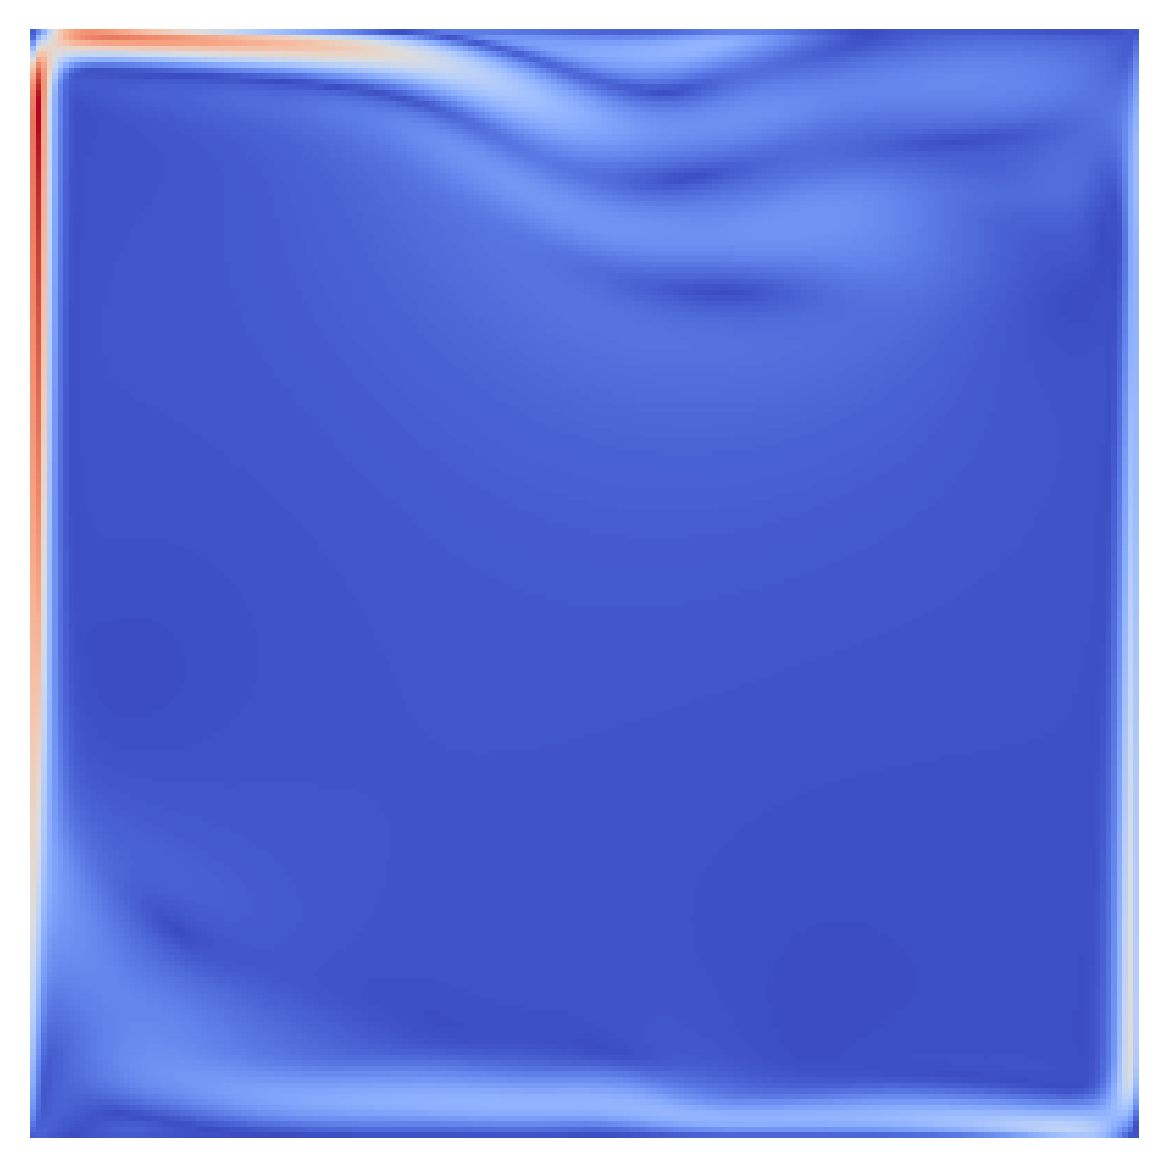

In [43]:
from matplotlib.colors import LinearSegmentedColormap
# You can use hex codes, RGB tuples, or standard color names.
lowest_color = "#FAFFB7"  # Navy Blue
highest_color = "#FF0026" # Yellow

# Optional: Add an intermediate color for a multi-color gradient
# mid_color = 'white'
# colors = [lowest_color, mid_color, highest_color]

colors = [lowest_color, highest_color]

# 2. Create the custom colormap
custom_cmap = LinearSegmentedColormap.from_list('my_cmap', colors)

# for key, val in image_dict.items():
# 	plt.imshow(val, cmap="coolwarm", origin='lower')
# 	plt.colorbar()
# 	plt.savefig(f"field_snapshots/{key}.png", bbox_inches='tight', pad_inches=0)
# 	plt.close()

plt.imshow(image_dict["GT_20"], cmap="coolwarm", origin='lower')
plt.axis('off')
plt.savefig(f"field_snapshots/GT_20.png", bbox_inches='tight', pad_inches=0)

# Figure 5

In [124]:

from collections import OrderedDict
from repitframework.plot_utils import load_metrics
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

prediction_metrics = "/home/shilaj/shilaj_data/repitframework/repitframework/ModelDump/natural_convection_case1_3D/prediction_metrics_backup_coarse.ndjson"
metrics = load_metrics(prediction_metrics)
time_list = metrics["Running Time"]

prediction_dir = "/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection_case1_3D_coarse"
ground_truth_dir = "/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection_case1_coarse_3D_backup"

grid_shape = (34, 34, 34)  # Example grid shape (nz, ny, nx)
nz, ny, nx = grid_shape
probes = OrderedDict({
		"B1": (nz // 2, 0, nx // 2),
		"B2": (0, 7, -7),
		"M1": (nz // 2, ny // 2, nx // 2),
		"T1": (nz-2, 2, 1),
		"T2": (nz -4, -2, -1),
	})

## 3D probe locations

In [103]:
#!/usr/bin/env python3
"""
Generates a publication-quality single-panel plot for 3D probe data and a
separate 3D visualization of the probe locations.

- Time-series plot: All probes on a single axis with moving average and std. dev.
- Location plot: Shows probe positions within a 3D wireframe of the domain.
"""
from collections import OrderedDict
from itertools import product, combinations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from typing import Tuple

# --- Matplotlib styling (Nature-like) ---
mpl.rcParams.update({
	"figure.dpi": 200,
	"savefig.dpi": 600,
	"font.family": "sans-serif",
	"font.size": 10,
	"axes.labelsize": 11,
	"axes.titlesize": 12,
	"axes.titleweight": "bold",
	"axes.labelweight": "bold",
	"axes.linewidth": 1.0,
	"xtick.labelsize": 9,
	"ytick.labelsize": 9,
	"legend.fontsize": 10,
	"axes.spines.top": False,
	"axes.spines.right": False,
})

def _calculate_velocity_magnitude(data: np.ndarray) -> np.ndarray:
	"""Calculates the magnitude of a velocity vector field."""
	return np.linalg.norm(data, axis=-1)

def _moving_average_std(data: np.ndarray, window: int | None) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
	"""Applies a moving average and std dev to a time series."""
	if not window or window <= 1 or len(data) < window:
		x = np.arange(len(data))
		return np.asarray(data, dtype=float), np.zeros_like(data, dtype=float), x

	series = pd.Series(data)
	rolling_mean = series.rolling(window=window, min_periods=1, center=True).mean().to_numpy()
	rolling_std = series.rolling(window=window, min_periods=1, center=True).std().to_numpy()
	return rolling_mean, rolling_std, np.arange(len(data))

def visualize_probe_locations_3d(probes: OrderedDict, colors: dict, grid_shape: tuple, savepath: str):
	"""Generates a 3D scatter plot showing the probe locations in a cube."""
	nz, ny, nx = grid_shape
	fig = plt.figure(figsize=(7, 7))
	ax = fig.add_subplot(111, projection='3d')

	# Draw the wireframe of the simulation domain cube
	r = [0, max(nx, ny, nz)]
	for s, e in combinations(np.array(list(product(r, r, r))), 2):
		if np.sum(np.abs(s-e)) == r[1]-r[0]:
			ax.plot3D(*zip(s, e), color="grey", linestyle="--", linewidth=0.7)

	# Plot each probe
	for name, (z, y, x) in probes.items():
		# Handle negative indices for correct plotting
		plot_y = ny + y if y < 0 else y
		plot_x = nx + x if x < 0 else x
		ax.scatter(plot_x, plot_y, z, c=colors[name], s=100, label=name, depthshade=True)
		ax.text(plot_x * 1.05, plot_y * 1.05, z * 1.05, name, fontsize=12)

	# Aesthetics
	ax.set_xlabel("X-axis")
	ax.set_ylabel("Z-axis")
	ax.set_zlabel("Y-axis")
	ax.view_init(elev=20, azim=-65)
	fig.savefig(savepath, bbox_inches="tight", pad_inches=0, transparent=True)
	plt.close(fig)
	print(f"3D probe location plot saved to {savepath}")


def visualize_probe_3d(
	predicted_dir: Path,
	ground_truth_dir: Path,
	time_list: list[float],
	variable: str = "velocity",
	grid_shape: tuple[int, int, int] = grid_shape,
	rolling: int | None = None,
	savepath: str = "velocity_probes_3D.png"
):
	"""
	Creates and saves a single-panel probe comparison plot with std. dev. shading.
	"""
	assert variable in {"velocity", "velocity_x", "velocity_y", "velocity_z", "temperature"}
	root_var = "U" if variable.startswith("velocity") else "T"
	idx_map = {"velocity_x": 0, "velocity_y": 1, "velocity_z": 2}
	var_idx = idx_map.get(variable)

	
	colors = {"T1":"#d62728","T2":"#ff7f0e","M1":"#2ca02c","B1":"#1f77b4","B2":"#9467bd"}
	
	# Generate the 3D location plot before the time-series plot
	visualize_probe_locations_3d(probes, colors, grid_shape, "probe_locations_3D.png")

	series = {k: {"gt": [], "pred": []} for k in probes}
	for t in sorted(time_list):
		try:
			pred_data = np.load(predicted_dir / f"{root_var}_{t}_predicted.npy")
		except:
			pred_data = np.load(predicted_dir / f"{root_var}_{t}.npy")
			
		gt_data = np.load(ground_truth_dir / f"{root_var}_{t}.npy")

		if root_var == "U":
			pred_field = pred_data.reshape(nz, ny, nx, 3)
			gt_field = gt_data.reshape(nz, ny, nx, 3)
			if variable == "velocity":
				pred_field = _calculate_velocity_magnitude(pred_field)
				gt_field = _calculate_velocity_magnitude(gt_field)
			else:
				pred_field = pred_field[..., var_idx]
				gt_field = gt_field[..., var_idx]
		else: # Temperature
			pred_field = pred_data.reshape(nz, ny, nx)
			gt_field = gt_data.reshape(nz, ny, nx)

		
		for name, idx in probes.items():
			series[name]["pred"].append(float(pred_field[idx]))
			series[name]["gt"].append(float(gt_field[idx]))

	# --- Plotting ---
	fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

	for name in probes.keys():
		color = colors[name]
		gt_mean, gt_std, x_gt = _moving_average_std(series[name]["gt"], rolling)
		pred_mean, pred_std, x_pred = _moving_average_std(series[name]["pred"], rolling)
		
		ax.plot(x_gt, gt_mean, color=color, lw=1.5, ls='-')
		ax.fill_between(x_gt, gt_mean - gt_std, gt_mean + gt_std, color=color, alpha=0.15)
		
		ax.plot(x_pred, pred_mean, color=color, lw=1.5, ls='--')
		ax.fill_between(x_pred, pred_mean - pred_std, pred_mean + pred_std, color=color, alpha=0.15)
		
	ylabel_map = {
		"velocity": "Velocity Magnitude (m/s)", "velocity_x": "U_x (m/s)",
		"velocity_y": "U_y (m/s)", "velocity_z": "U_z (m/s)",
		"temperature": "Temperature (K)",
	}
	ax.set_ylabel(ylabel_map[variable])
	ax.set_xlabel("Timestep")
	ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
	
	color_handles = [Line2D([0], [0], color=c, lw=2, label=n) for n, c in colors.items()]
	style_handles = [
		Line2D([0], [0], color='black', lw=1.5, ls='-', label='Ground Truth'),
		Line2D([0], [0], color='black', lw=1.5, ls='--', label='Prediction'),
	]
	
	fig.legend(handles=color_handles + style_handles, loc='upper center', 
			   bbox_to_anchor=(0.5, 1.07), ncol=7, frameon=False)
	
	fig.savefig(savepath, bbox_inches="tight", transparent=True)
	plt.close(fig)
	print(f"Single-panel probe plot saved to {savepath}")


In [125]:
visualize_probe_3d(
	predicted_dir=Path(prediction_dir),
	ground_truth_dir=Path(ground_truth_dir),
	time_list=time_list,
	variable="velocity",
	grid_shape=grid_shape,
	rolling=500,
	savepath="probe_comparison_3D_velocity.png"
)

3D probe location plot saved to probe_locations_3D.png
Single-panel probe plot saved to probe_comparison_3D_velocity.png


## Plotting errors for 3D

In [126]:
#!/usr/bin/env python3
"""
Generates a publication-quality plot of the error for 3D probe data,
comparing velocity components and temperature on a dual-axis plot.

- Supports multiple error metrics:
  - relative_l2_probes: Relative L2 Error at probe locations.
  - mse_probes: Mean Squared Error at probe locations.
  - relative_l2_field: Relative L2 Error over the entire field.
  - mse_field: Mean Squared Error over the entire field.
- Applies a moving average to smooth the trends.
- Velocity component errors are plotted on the left Y-axis.
- Temperature error is plotted on the right Y-axis.
- Uses professional, "Nature-ready" styling with a clean, horizontal legend.
"""
from collections import OrderedDict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from typing import Tuple, Dict

# --- Matplotlib styling (Nature-like) ---
mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.0,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "axes.spines.top": False,
})

def _moving_average_std(data: np.ndarray, window: int | None) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Applies a moving average and std dev to a time series."""
    if not window or window <= 1 or len(data) < window:
        x = np.arange(len(data))
        return np.asarray(data, dtype=float), np.zeros_like(data, dtype=float), x
    series = pd.Series(data)
    rolling_mean = series.rolling(window=window, min_periods=1, center=True).mean().to_numpy()
    rolling_std = series.rolling(window=window, min_periods=1, center=True).std().to_numpy()
    return rolling_mean, rolling_std, np.arange(len(data))

def visualize_probe_error_3d(
    predicted_dir: Path,
    ground_truth_dir: Path,
    time_list: list[float],
    grid_shape: tuple[int, int, int] = (34, 34, 34),
    rolling: int | None = 25,
    error_metric: str = "relative_l2_probes",
    savepath: str = "probe_error_comparison_3D.png"
):
    """
    Creates and saves a dual-axis error plot for velocity and temperature.
    """
    assert error_metric in {
        "relative_l2_probes", "mse_probes",
        "relative_l2_field", "mse_field"
    }, "Invalid error_metric specified."

    nz, ny, nx = grid_shape
    probes = OrderedDict({
        "B1": (nz // 2, 0, nx // 2),
        "B2": (3, 1, nx // 2),
        "M1": (nz // 2, ny // 2, nx // 2),
        "T1": (nz // 2, -1, nx // 2 - 3),
        "T2": (nz // 2 - 3, -2, -1),
    })

    errors = {var: [] for var in ["U_x", "U_y", "U_z", "T"]}

    for t in sorted(time_list):

        try:
            pred_U = np.load(predicted_dir / f"U_{t}_predicted.npy").reshape(nz, ny, nx, 3)
            pred_T = np.load(predicted_dir / f"T_{t}_predicted.npy").reshape(nz, ny, nx)
        except:
            pred_U = np.load(predicted_dir / f"U_{t}.npy").reshape(nz, ny, nx, 3)
            pred_T = np.load(predicted_dir / f"T_{t}.npy").reshape(nz, ny, nx)
        
        gt_U = np.load(ground_truth_dir / f"U_{t}.npy").reshape(nz, ny, nx, 3)
        
        gt_T = np.load(ground_truth_dir / f"T_{t}.npy").reshape(nz, ny, nx)
        

        if "probes" in error_metric:
            gt_probe_vals = {var: [] for var in errors.keys()}
            pred_probe_vals = {var: [] for var in errors.keys()}
            for _, idx in probes.items():
                gt_probe_vals["U_x"].append(gt_U[idx][0])
                pred_probe_vals["U_x"].append(pred_U[idx][0])
                gt_probe_vals["U_y"].append(gt_U[idx][1])
                pred_probe_vals["U_y"].append(pred_U[idx][1])
                gt_probe_vals["U_z"].append(gt_U[idx][2])
                pred_probe_vals["U_z"].append(pred_U[idx][2])
                gt_probe_vals["T"].append(gt_T[idx])
                pred_probe_vals["T"].append(pred_T[idx])
            
            for var in errors.keys():
                gt_vec = np.array(gt_probe_vals[var])
                pred_vec = np.array(pred_probe_vals[var])
                if error_metric == "relative_l2_probes":
                    norm_diff = np.linalg.norm(gt_vec - pred_vec)
                    norm_gt = np.linalg.norm(gt_vec)
                    errors[var].append(norm_diff / norm_gt if norm_gt > 1e-9 else 0)
                elif error_metric == "mse_probes":
                    errors[var].append(np.mean((gt_vec - pred_vec)**2))

        elif "field" in error_metric:
            if error_metric == "relative_l2_field":
                errors["U_x"].append(np.linalg.norm(gt_U[...,0] - pred_U[...,0]) / np.linalg.norm(gt_U[...,0]))
                errors["U_y"].append(np.linalg.norm(gt_U[...,1] - pred_U[...,1]) / np.linalg.norm(gt_U[...,1]))
                errors["U_z"].append(np.linalg.norm(gt_U[...,2] - pred_U[...,2]) / np.linalg.norm(gt_U[...,2]))
                errors["T"].append(np.linalg.norm(gt_T - pred_T) / np.linalg.norm(gt_T))
            elif error_metric == "mse_field":
                errors["U_x"].append(np.mean((gt_U[...,0] - pred_U[...,0])**2))
                errors["U_y"].append(np.mean((gt_U[...,1] - pred_U[...,1])**2))
                errors["U_z"].append(np.mean((gt_U[...,2] - pred_U[...,2])**2))
                errors["T"].append(np.mean((gt_T - pred_T)**2))

    # --- Plotting ---
    fig, ax_vel = plt.subplots(figsize=(10, 6), constrained_layout=True)
    ax_temp = ax_vel.twinx()

    colors = {"U_x": "#1f77b4", "U_y": "#ff7f0e", "U_z": "#2ca02c", "T": "#d62728"}
    linestyles = {"U_x": "--", "U_y": "--", "U_z": "--", "T": "-"}

    for var in ["U_x", "U_y", "U_z"]:
        mean_err, std_err, x = _moving_average_std(errors[var], rolling)
        ax_vel.plot(x, mean_err, color=colors[var], linestyle=linestyles[var], label=var)
        ax_vel.fill_between(x, mean_err - std_err, mean_err + std_err, color=colors[var], alpha=0.1)

    mean_err, std_err, x = _moving_average_std(errors["T"], rolling)
    ax_temp.plot(x, mean_err, color=colors["T"], linestyle=linestyles["T"], label="T")
    ax_temp.fill_between(x, mean_err - std_err, mean_err + std_err, color=colors["T"], alpha=0.1)

    # --- Aesthetics and Labels ---
    error_labels = {
        "relative_l2_probes": "Relative L2 Error", "mse_probes": "Mean Squared Error",
        "relative_l2_field": "Relative L2 Error", "mse_field": "Mean Squared Error"
    }
    ylabel_base = error_labels[error_metric]
    ax_vel.set_xlabel("Timestep")
    ax_vel.set_ylabel(f"{ylabel_base} (Velocity)", color='black')
    ax_temp.set_ylabel(f"{ylabel_base} (Temperature, K)", color='#d62728')
    
    ax_vel.tick_params(axis='y', labelcolor=colors["U_x"])
    ax_temp.tick_params(axis='y', labelcolor=colors["T"])
    
    ax_vel.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
    ax_vel.autoscale(enable=True, axis='x', tight=True)

    # --- Consolidated Legend ---
    lines_vel, labels_vel = ax_vel.get_legend_handles_labels()
    lines_temp, labels_temp = ax_temp.get_legend_handles_labels()
    fig.legend(lines_vel + lines_temp, labels_vel + labels_temp, loc='upper center',
               bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False)
    
    fig.savefig(savepath, bbox_inches="tight", transparent=True)
    plt.close(fig)
    print(f"Probe error plot saved to {savepath}")


In [127]:
visualize_probe_error_3d(
	predicted_dir=Path(prediction_dir),
	ground_truth_dir=Path(ground_truth_dir),
	time_list=time_list,
    error_metric="mse_field",
	rolling=500
)


Probe error plot saved to probe_error_comparison_3D.png


# Networks comparison

In [2]:
import numpy as np 

model2_dir = "/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection_case1_study/10000timesteps/2epochs5res_FVFNO1D/natural_convection_case1"
model1_dir = "/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection_case1_study/10000timesteps/2epochs5res_FVMN/natural_convection_case1"
ground_truth_dir = "/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection_case1_backup"
time_list = np.round(np.arange(10.0, 110.0, 0.01), 2)

## Error comparison

In [7]:
#!/usr/bin/env python3
"""
Generates a publication-quality plot to compare the whole-field errors of two
neural network models against a ground truth dataset.

- Compares two models for both velocity and temperature in 2D or 3D.
- Supports two whole-field error metrics:
  - 'relative_l2_field': Relative L2 Error over the entire domain.
  - 'mse_field': Mean Squared Error over the entire domain.
- Uses a dual-axis plot:
  - Left Y-axis: Velocity Magnitude Error.
  - Right Y-axis: Temperature Error.
- Visual style:
  - Color distinguishes the two models.
  - Line style distinguishes velocity (dotted) from temperature (solid).
- Applies a moving average and standard deviation shading for trend clarity.
"""
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from typing import Tuple

# --- Matplotlib styling (Nature-like) ---
mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.2,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.spines.top": False,
})

def _moving_average_std(data: np.ndarray, window: int | None) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Applies a moving average and std dev to a time series."""
    if not window or window <= 1 or len(data) < window:
        x = np.arange(len(data))
        return np.asarray(data, dtype=float), np.zeros_like(data, dtype=float), x
    series = pd.Series(data)
    rolling_mean = series.rolling(window=window, min_periods=1, center=True).mean().to_numpy()
    rolling_std = series.rolling(window=window, min_periods=1, center=True).std().to_numpy()
    return rolling_mean, rolling_std, np.arange(len(data))

def calculate_field_error(gt_field: np.ndarray, pred_field: np.ndarray, metric: str) -> float:
    """Calculates the error between two fields using the specified metric."""
    if metric == 'relative_l2_field':
        norm_diff = np.linalg.norm(gt_field - pred_field)
        norm_gt = np.linalg.norm(gt_field)
        return norm_diff / norm_gt if norm_gt > 1e-9 else 0.0
    elif metric == 'mse_field':
        return np.mean((gt_field - pred_field)**2)
    return 0.0

def visualize_model_comparison(
    model1_dir: Path,
    model2_dir: Path,
    ground_truth_dir: Path,
    time_list: list[float],
    error_metric: str,
    grid_shape: tuple = (200, 200),
    rolling: int | None = 25,
    savepath: str = "model_error_comparison.png"
):
    """
    Creates a dual-axis plot comparing the errors of two models.
    """
    assert error_metric in {"relative_l2_field", "mse_field"}, "Invalid error_metric."
    data_dim = len(grid_shape)
    assert data_dim in {2, 3}, "grid_shape must be a 2D or 3D tuple."

    errors = {
        "model1_U_mag": [], "model1_T": [],
        "model2_U_mag": [], "model2_T": []
    }

    for t in sorted(time_list):
        # --- Load Ground Truth Data ---
        gt_U = np.load(ground_truth_dir / f"U_{t}.npy")[..., :data_dim].reshape(*grid_shape, data_dim)
        gt_T = np.load(ground_truth_dir / f"T_{t}.npy").reshape(*grid_shape)
        
        # --- Load Model 1 Data (with fallback for different naming conventions) ---
        try:
            m1_U = np.load(model1_dir / f"U_{t}_predicted.npy").reshape(*grid_shape, data_dim)
            m1_T = np.load(model1_dir / f"T_{t}_predicted.npy").reshape(*grid_shape)
        except FileNotFoundError:
            m1_U = np.load(model1_dir / f"U_{t}.npy")[..., :data_dim].reshape(*grid_shape, data_dim)
            m1_T = np.load(model1_dir / f"T_{t}.npy").reshape(*grid_shape)

        # --- Load Model 2 Data (with fallback) ---
        try:
            m2_U = np.load(model2_dir / f"U_{t}_predicted.npy").reshape(*grid_shape, data_dim)
            m2_T = np.load(model2_dir / f"T_{t}_predicted.npy").reshape(*grid_shape)
        except FileNotFoundError:
            m2_U = np.load(model2_dir / f"U_{t}.npy")[..., :data_dim].reshape(*grid_shape, data_dim)
            m2_T = np.load(model2_dir / f"T_{t}.npy").reshape(*grid_shape)
        
        # Calculate velocity magnitudes
        gt_U_mag = np.linalg.norm(gt_U, axis=-1)
        m1_U_mag = np.linalg.norm(m1_U, axis=-1)
        m2_U_mag = np.linalg.norm(m2_U, axis=-1)
        
        # Calculate and store errors
        errors["model1_U_mag"].append(calculate_field_error(gt_U_mag, m1_U_mag, error_metric))
        errors["model2_U_mag"].append(calculate_field_error(gt_U_mag, m2_U_mag, error_metric))
        errors["model1_T"].append(calculate_field_error(gt_T, m1_T, error_metric))
        errors["model2_T"].append(calculate_field_error(gt_T, m2_T, error_metric))

    # --- Plotting ---
    fig, ax_vel = plt.subplots(figsize=(10, 6), constrained_layout=True)
    ax_temp = ax_vel.twinx()

    colors = {"model1": "#0072B2", "model2": "#D55E00"} # Blue for Model 1, Orange for Model 2
    
    # --- Plot Velocity Magnitude Errors (Left Axis, Dotted) ---
    m1_vel_mean, m1_vel_std, x1 = _moving_average_std(errors["model1_U_mag"], rolling)
    ax_vel.plot(x1, m1_vel_mean, color=colors["model1"], linestyle='--', lw=1.8, label="Model A Velocity Mag.")
    ax_vel.fill_between(x1, m1_vel_mean - m1_vel_std, m1_vel_mean + m1_vel_std, color=colors["model1"], alpha=0.15)

    m2_vel_mean, m2_vel_std, x2 = _moving_average_std(errors["model2_U_mag"], rolling)
    ax_vel.plot(x2, m2_vel_mean, color=colors["model2"], linestyle='--', lw=1.8, label="Model B Velocity Mag.")
    ax_vel.fill_between(x2, m2_vel_mean - m2_vel_std, m2_vel_mean + m2_vel_std, color=colors["model2"], alpha=0.15)

    # --- Plot Temperature Errors (Right Axis, Solid) ---
    m1_T_mean, m1_T_std, x3 = _moving_average_std(errors["model1_T"], rolling)
    ax_temp.plot(x3, m1_T_mean, color=colors["model1"], linestyle='-', lw=1.8, label="Model A Temperature")
    ax_temp.fill_between(x3, m1_T_mean - m1_T_std, m1_T_mean + m1_T_std, color=colors["model1"], alpha=0.15)

    m2_T_mean, m2_T_std, x4 = _moving_average_std(errors["model2_T"], rolling)
    ax_temp.plot(x4, m2_T_mean, color=colors["model2"], linestyle='-', lw=1.8, label="Model B Temperature")
    ax_temp.fill_between(x4, m2_T_mean - m2_T_std, m2_T_mean + m2_T_std, color=colors["model2"], alpha=0.15)

    # --- Aesthetics and Labels ---
    error_label = "Relative L2 Error" if "relative_l2" in error_metric else "Mean Squared Error"
    ax_vel.set_xlabel("Timestep")
    ax_vel.set_ylabel(f"{error_label} (Velocity Magnitude)", color='black')
    ax_temp.set_ylabel(f"{error_label} (Temperature)", color='black')
    
    ax_vel.tick_params(axis='y', labelcolor=colors["model1"])
    ax_temp.tick_params(axis='y', labelcolor=colors["model2"])
    
    ax_vel.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
    ax_vel.autoscale(enable=True, axis='x', tight=True)

    # --- Consolidated Legend ---
    handles = [
        Line2D([0], [0], color=colors["model1"], lw=2, label='FVMN'),
        Line2D([0], [0], color=colors["model2"], lw=2, label='FVFNO-1D'),
        Line2D([0], [0], color='black', lw=1.8, ls='--', label='Velocity Magnitude'),
        Line2D([0], [0], color='black', lw=1.8, ls='-', label='Temperature'),
    ]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False)
    
    fig.savefig(savepath, bbox_inches="tight", transparent=True)
    plt.close(fig)
    print(f"Model comparison plot saved to {savepath}")


visualize_model_comparison(
    model1_dir=Path(model1_dir),
    model2_dir=Path(model2_dir),
    ground_truth_dir=Path(ground_truth_dir),
    time_list=time_list,
    error_metric="relative_l2_field",
    grid_shape=(200,200), # Pass the 2D shape
    rolling=500,
    savepath="model_comparison_relative_l2_2D.png"
)


Model comparison plot saved to model_comparison_relative_l2_2D.png


## ML timesteps per switch

In [7]:
#!/usr/bin/env python3
"""
Generates a publication-quality plot comparing the number of ML steps between
CFD solver switches for two different models.

- Plots the number of consecutive ML steps (n_ML) against cumulative simulation time.
- Compares two models (e.g., FVMN and FNO2D).
- Includes horizontal lines indicating the average n_ML for each model.
- Uses professional, "Nature-ready" styling for clarity and impact.
"""
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from typing import Tuple
from repitframework.plot_utils import load_metrics

# --- Matplotlib styling (Nature-like) ---
mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.2,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def process_switch_data(df: pd.DataFrame) -> Tuple[pd.DataFrame, float]:
    """
    Processes the raw metrics DataFrame to calculate switch counts and cumulative timesteps.
    """
    counter = 0
    timesteps = []
    n_ML_counter = 0
    
    # Identify switch points
    df['is_switch'] = df["Relative Residual Mass"] >= 5.0
    df['switch_group'] = df['is_switch'].cumsum()

    # Calculate steps per switch cycle
    df_grouped = df.groupby('switch_group').size().reset_index(name='Count')
    
    # Calculate cumulative time
    df['TimestepValue'] = np.where(df['is_switch'], 11, 1)
    df_time_sum = df.groupby('switch_group')['TimestepValue'].sum().reset_index()
    df_time_sum['CumulativeTime'] = df_time_sum['TimestepValue'].cumsum()

    # Combine results
    df_final = df_grouped.merge(df_time_sum[['switch_group', 'CumulativeTime']], on='switch_group')
    
    avg_n_ml = df_final['Count'].mean()
    
    return df_final, avg_n_ml

def visualize_switch_comparison(
    case_path1: Path,
    case_path2: Path,
    model_names: Tuple[str, str] = ("Model A", "Model B"),
    savepath: str = "nML_comparison.png"
):
    """
    Creates and saves the final comparison plot.
    """
    # --- Data Processing ---
    df1 = pd.DataFrame(load_metrics(case_path1))
    df2 = pd.DataFrame(load_metrics(case_path2))
    
    df1_final, avg_n_ml1 = process_switch_data(df1)
    df2_final, avg_n_ml2 = process_switch_data(df2)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    
    colors = {"model1": "#0072B2", "model2": "#D55E00"}
    # --- Plot Model 1 (e.g., FVMN) ---
    ax.plot(
        df1_final["CumulativeTime"][:-1], df1_final["Count"][:-1],
        marker='o', markersize=6, linestyle='-', color=colors["model1"], 
        linewidth=2.5, label=model_names[0]
    )
    ax.axhline(
        avg_n_ml1, color=colors["model1"], linestyle='--', linewidth=1.5,
        label=fr"Avg. $n_{{ML}}$ ({model_names[0]}): {avg_n_ml1:.2f}"
    )

    # --- Plot Model 2 (e.g., FNO2D) ---
    ax.plot(
        df2_final["CumulativeTime"][:-1], df2_final["Count"][:-1],
        marker='s', markersize=6, linestyle='-', color=colors["model2"], 
        linewidth=2.5, label=model_names[1]
    )
    ax.axhline(
        avg_n_ml2, color=colors["model2"], linestyle='--', linewidth=1.5,
        label=fr"Avg. $n_{{ML}}$ ({model_names[1]}): {avg_n_ml2:.2f}"
    )

    # --- Aesthetics and Labels ---
    ax.set_xlabel("Timestep")
    ax.set_ylabel("ML timestep per switch")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.autoscale(enable=True, axis='x', tight=True)
    ax.set_ylim(bottom=0)

    # --- Consolidated Legend ---
    # Manually create handles to control order and style
    handles = [
        Line2D([0], [0], color=colors["model1"], marker='o', markersize=6, lw=2.5, label=model_names[0]),
        Line2D([0], [0], color=colors["model2"], marker='s', markersize=6, lw=2.5, label=model_names[1]),
        Line2D([0], [0], color=colors["model1"], ls='--', lw=1.5, label=f'Avg. {model_names[0]}'),
        Line2D([0], [0], color=colors["model2"], ls='--', lw=1.5, label=f'Avg. {model_names[1]}'),
    ]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False)
    
    fig.savefig(savepath, bbox_inches='tight', transparent=True, dpi=600)
    plt.close(fig)
    print(f"Switch comparison plot saved to {savepath}")


case_path1 = Path("/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection_case1_study/10000timesteps/2epochs5res_FVMN/prediction_metrics.ndjson")
case_path2 = Path("/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection_case1_study/10000timesteps/2epochs5res_FVFNO1D/prediction_metrics.ndjson")

visualize_switch_comparison(
    case_path1=case_path1,
    case_path2=case_path2,
    model_names=("FVMN", "FVFNO1D"),
    savepath="nML_comparison.png"
)


Switch comparison plot saved to nML_comparison.png
